In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv("train.csv")

print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [8]:
df = df.drop(columns=["Cabin", "Name", "Ticket", "PassengerId"])

In [9]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

df["Embarked"] = df["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

In [10]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [11]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


In [12]:
print(df.dtypes)

Survived      int64
Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
dtype: object


In [13]:
print("Розмір таблиці після обробки:", df.shape)

Розмір таблиці після обробки: (891, 8)


In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [16]:
print("Розмір X:", X.shape)
print("Розмір y:", y.shape)

Розмір X: (891, 7)
Розмір y: (891,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
print("Розмір навчальної вибірки X_train:", X_train.shape)
print("Розмір тестової вибірки X_test:", X_test.shape)

print("Розмір навчальної вибірки y_train:", y_train.shape)
print("Розмір тестової вибірки y_test:", y_test.shape)

Розмір навчальної вибірки X_train: (712, 7)
Розмір тестової вибірки X_test: (179, 7)
Розмір навчальної вибірки y_train: (712,)
Розмір тестової вибірки y_test: (179,)


In [19]:
print("Баланс класів у train:")
print(y_train.value_counts())

print()

print("Баланс класів у test:")
print(y_test.value_counts())

Баланс класів у train:
Survived
0    439
1    273
Name: count, dtype: int64

Баланс класів у test:
Survived
0    110
1     69
Name: count, dtype: int64


In [20]:
from sklearn.tree import DecisionTreeClassifier

In [21]:
model = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

model.fit(X_train, y_train);

In [22]:
y_pred = model.predict(X_test)

In [23]:
print("Прогнози моделі:")
print(y_pred[:20])

Прогнози моделі:
[0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1]


In [24]:
print("Реальні значення:")
print(y_test.values[:20])

Реальні значення:
[0 0 1 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1]


In [25]:
print("Глибина дерева:", model.get_depth())
print("Кількість вузлів:", model.tree_.node_count)

Глибина дерева: 4
Кількість вузлів: 29


In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [27]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.7877094972067039
Precision: 0.8604651162790697
Recall: 0.5362318840579711
F1-score: 0.6607142857142857


In [28]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[104   6]
 [ 32  37]]


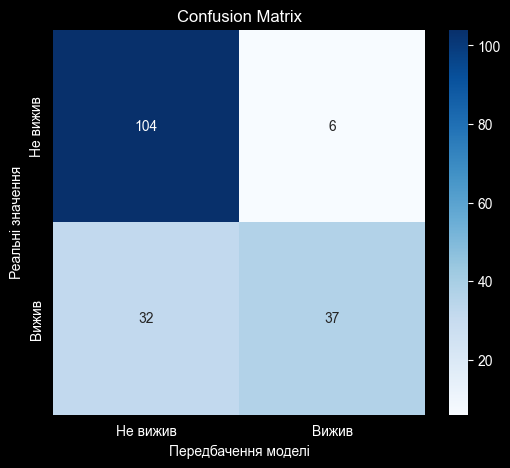

In [29]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Не вижив", "Вижив"],
    yticklabels=["Не вижив", "Вижив"]
)

plt.xlabel("Передбачення моделі")
plt.ylabel("Реальні значення")
plt.title("Confusion Matrix")

plt.show()

In [30]:
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.76      0.95      0.85       110
           1       0.86      0.54      0.66        69

    accuracy                           0.79       179
   macro avg       0.81      0.74      0.75       179
weighted avg       0.80      0.79      0.77       179



In [31]:
print("Баланс класів у всьому датасеті:")
print(y.value_counts(normalize=True))

Баланс класів у всьому датасеті:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [32]:
from sklearn.tree import plot_tree

In [33]:
feature_importance = pd.DataFrame({
    "Ознака": X.columns,
    "Важливість": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Важливість",
    ascending=False
)

feature_importance

,Ознака,Важливість
1,Sex,0.576297
0,Pclass,0.195920
2,Age,0.123665
5,Fare,0.054002
6,Embarked,0.037198
3,SibSp,0.012109
4,Parch,0.000809


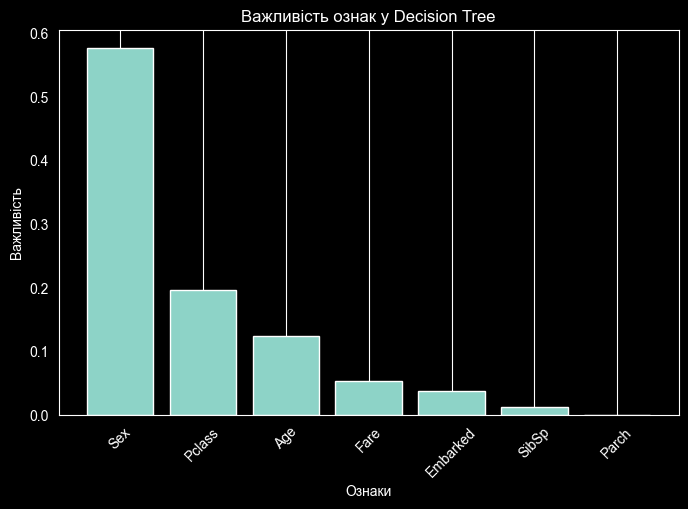

In [34]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Ознака"],
    feature_importance["Важливість"]
)

plt.xlabel("Ознаки")
plt.ylabel("Важливість")
plt.title("Важливість ознак у Decision Tree")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

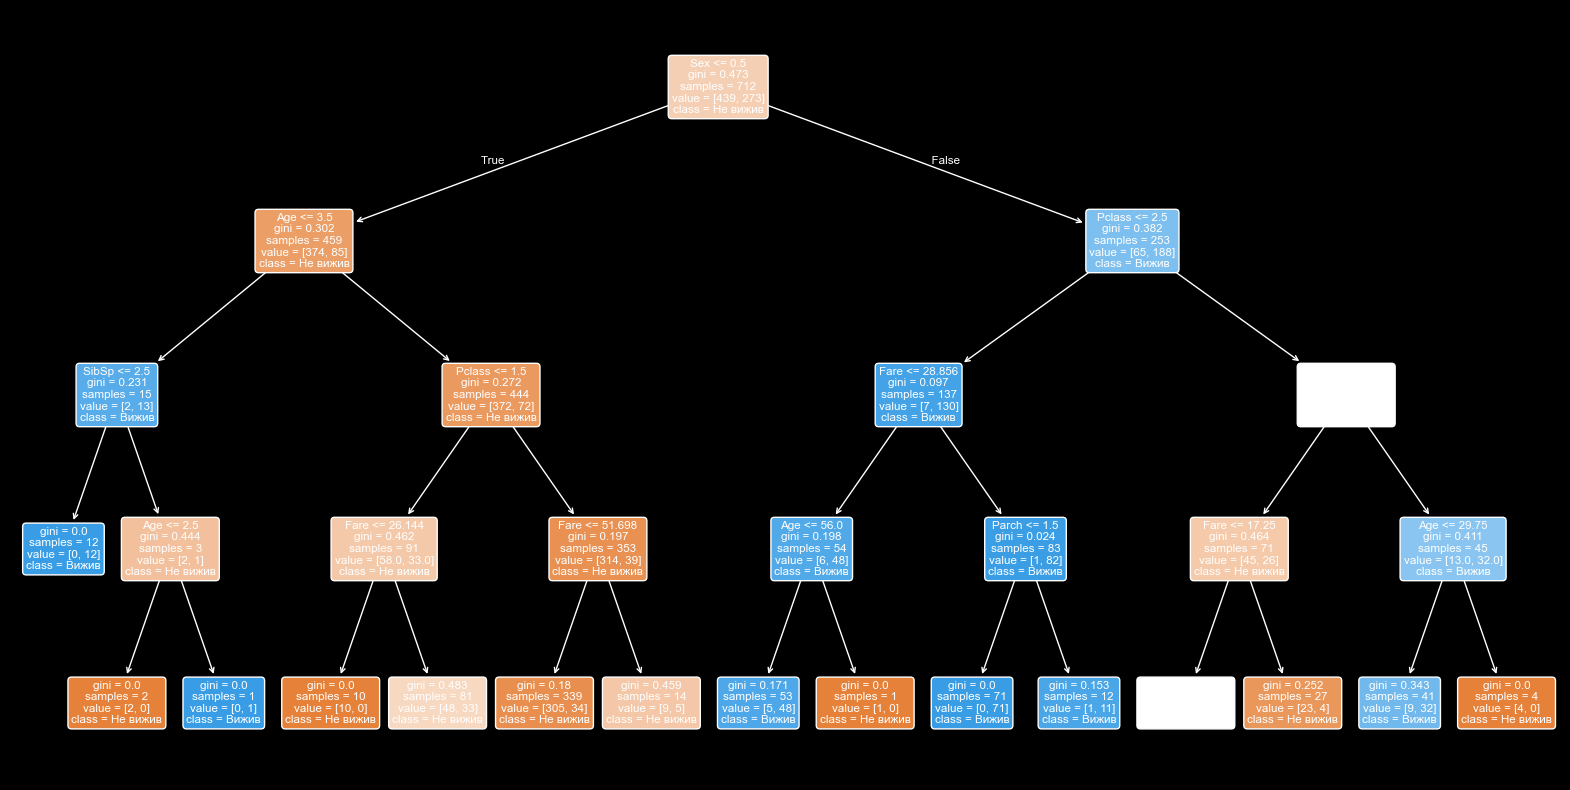

In [35]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Не вижив", "Вижив"],
    filled=True,
    rounded=True
)

plt.show()

In [36]:
print("Найважливіші ознаки:")
print(feature_importance.head())

Найважливіші ознаки:
     Ознака  Важливість
1       Sex    0.576297
0    Pclass    0.195920
2       Age    0.123665
5      Fare    0.054002
6  Embarked    0.037198
